<a href="https://colab.research.google.com/github/Brunolms11/Calc_Numerico/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
r=0.4000000059604645
dy = 0.0005
dt=0.001, float32: 2000 passos sem overflow.
r=0.800000011920929
dy = 0.0005
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
r=0.4000000000000001
dy = 0.0005
dt=0.001, float64: 2000 passos sem overflow.
r=0.8000000000000002
dy = 0.0005
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


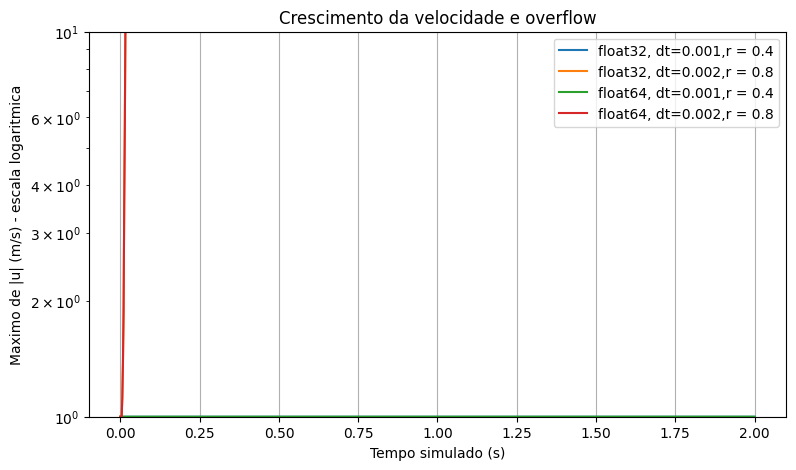

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    #r=0.4
    print(f"r={r}")
    print(f"dy = {dy}")
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                    #f"r={r}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        r = 0.4 if dt == 0.001 else 0.8
        nome = f"{tipo.__name__}, dt={dt},r = {r}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

#6.1
dy =0.0005 nos dois casos
(CASO A)


∆tmax = 0.001

r= 0.04

(CASO B)

∆tmax = 0.002

r=0.8

temos que os caso B é sempre instável, pois sempre que r = 0.8, t =0.002, e temos que  ∆tmax =
(0,0005)^2/2 × 10−4
= 0,00125 s.

ou seja, quando t = 0.002 ele ultrapassa o limite, fazendo com que u também ultrapasse o limite.

#6.2


#6.3
os casos instaveis são fisicamente incorretores pois a tendência de umax é constinuar crescendo, ultrapassando o limite teórico físico expresso em 0 ≤ u(y, t) ≤ U. Ou seja, nos casos instáveis a tendência é u > U

#6.4
O tipo númerico não isenta a execução de erros, porém permite um maior número de passos. No exemplo dado, a quantidade de passos saltou de 121 para 917, quando saíamos de float32 para float64.